# Floodnet API Access using Python
> I've updated the API examples to utilize REST API endpoints.

This notebook will show you how to accomplish:
 - Querying all deployed Floodnet sensors
 - Querying sensors near a specific location
 - Querying the data for sensors within a specific time range

## Setup

In [ ]:
# they are likely already installed
# !pip install requests folium humanize pandas

In [ ]:
# for making API requests
import requests
# showing Maps
import folium
import folium.plugins
# standard data processing and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rc('figure', figsize=(15, 4))

## Where are the sensors located?

The places where sensors are mounted are referred to as *Deployments*. Each deployment represents a single sensor mounted in a single location.

The returned fields are:
 - **`name`**: The name of the sensor.
 - **`location`**: A [GeoJSON](https://geojson.org/) geometry representation of the sensor location. The `crs` key defines the map projection. We return the commonly used WGS84 projection.
 - **`deployment_id`**: The unique ID representing the sensor. **You can use this as the ID to query data for a specific sensor.**
 - **`date_deployed`**: The date that the sensor was deployed.
 - **`date_down`**: The date that the sensor was taken down (if at all).
 - **`deploy_type`**: The type of a sensor:
    - pluvial: The sensor is primarily driven by pluvial/rainstorm flooding
    - coastal: The sensor is primarily driven by coastal/tidal flooding

### Querying the data
We're going to:
 - request the data from the API
 - load it using [Pandas](https://pandas.pydata.org/docs/index.html) (a tabular data library)

In [ ]:
def get_deployments():
    '''Retrieve a table of all sensor deployment locations.

    '''
    # query the API
    deployments = requests.get("https://api.floodnet.nyc/api/rest/deployments/flood").json()
    if 'error' in deployments:
        raise RuntimeError(str(deployments))

    # create a pandas table
    df = pd.DataFrame(deployments['deployments'])

    # drop any sensors without a location (TODO: do this within the query)
    df = df.dropna(subset=['location'])

    # convert date strings to datetime objects
    df['date_deployed'] = pd.to_datetime(df.date_deployed).dt.tz_localize(tz='America/New_York')
    df['date_down'] = pd.to_datetime(df.date_down).dt.tz_localize(tz='America/New_York')

    # extract latitude, longitude pair
    df['coordinates'] = [np.array(x['coordinates'][::-1]) for x in df.location]
    return df

In [ ]:
# get a dataframe of flood deployments
df_deployments = get_deployments()

# show a summary
print(len(df_deployments), "results")
df_deployments.head()

112 results


,name,deployment_id,date_deployed,date_down,deploy_type,location,image,sensor_mount,mounted_over,sensor_status,coordinates
0,Q - 1st St/104th St,big_pink_elephant,2023-03-17 00:00:00-04:00,NaT,coastal,"{'type': 'Point', 'crs': {'type': 'name', 'pro...",None,streetsign post,sidewalk,up,"[40.6559075, -73.828642]"
1,Q - 159th St/109th Ave,boring_olive_stingray,2022-06-10 00:00:00-04:00,NaT,pluvial,"{'type': 'Point', 'crs': {'type': 'name', 'pro...",None,streetsign post,sidewalk,retired,"[40.69395022, -73.79308702]"
2,BK - Walton St/Marcy Ave,clearly_bored_turtle,2023-03-09 00:00:00-05:00,NaT,pluvial,"{'type': 'Point', 'crs': {'type': 'name', 'pro...",None,streetsign post,sidewalk,up,"[40.70082053, -73.95133488]"
3,Q - 30th Ave/89th St,closely_muddy_scurvy,2024-01-12 00:00:00-05:00,NaT,pluvial,"{'type': 'Point', 'crs': {'type': 'name', 'pro...",None,streetsign post,sidewalk,up,"[40.76183408, -73.87997808]"
4,Q - Beach 84 St,daily_happy_satyr,2021-12-10 00:00:00-05:00,NaT,coastal,"{'type': 'Point', 'crs': {'type': 'name', 'pro...",None,fence,sidewalk,up,"[40.59136, -73.80996]"


### Visualizing the data
 - draw markers on a map using a mapping library called [Folium](https://python-visualization.github.io/folium/latest/)
 - use different styles to differentiate sensors
    - retired sensors (sensors that are no longer up) will be drawn in red
    - pluvial sensors will be drawn in dark blue with a rain icon
    - coastal sensors will be drawn in light blue with a wave icon

In [ ]:
def draw_markers(map, df):
    '''Draw sensor markers on a map.
    '''
    # Add markers for each deployment location
    for _, row in df.iterrows():
        # show different icon styles based on sensor data
        icon_kw = {}
        if row.deploy_type == 'coastal':
            icon_kw.update(dict(color='blue', icon='water'))
        else:
            icon_kw.update(dict(color='darkblue', icon='cloud-rain'))
        if not pd.isna(row.date_down):
            icon_kw['color'] = 'red'

        # draw marker
        folium.Marker(
            row.coordinates,
            icon=folium.Icon(prefix='fa', **icon_kw),
            tooltip=f"<b>{row['name']}</b>",
            popup=folium.Popup(
                f"<b style=\"font-size: 1.3em\">{row['name']}</b><br>"
                f"<b>Deploy Type</b>: {row.deploy_type}<br>"
                f"<b>Date Deployed</b>: {row.date_deployed.strftime('%b %d, %Y')}<br>"
                f"<b>Date Down</b>: {row.date_down.strftime('%b %d, %Y') if not pd.isna(row.date_down) else '--'}<br>"
                f"<b>Location</b>: {row.coordinates.tolist()}<br>"
            , max_width=200)
        ).add_to(map)

In [ ]:
# get the center of the map using the average of sensor coordinates
map_center = df_deployments.coordinates.dropna().mean(0)

# let's create the map
map = folium.Map(location=map_center, zoom_start=11, tiles="CartoDB Positron", attr="CartoDB")
folium.plugins.ScrollZoomToggler().add_to(map)  # disables scroll-zoom by default

# draw the markers
draw_markers(map, df_deployments)

# Display the map
map

## Can we search in a specific area?

You can also do geographical queries like this! Just specify a latitude, longitude, and search radius in units of meters.

If you need help getting your location, you can try:
 - [Address reverse geocode](https://www.latlong.net/)
 - Google Maps
    - Find your current location on the map
    - Click on blank space near your location (anywhere without a specific address)
    - this should show a little box at the bottom of the screen with two numbers in blue:
        - latitude (a number around 40 to 41)
        - longitude (a number around -73 to -74)
 - Use the coordinates of an existing sensor (see map above)


### Querying the data
Let's search around the Gowanus Canal.

We're going to:
 - request the data from the API using query parameters to specify where we want to search.
 - load the data using Pandas

 > The API limits the response to 3000 rows. This equates to around 2 days of data (assuming upload rate of 1 message per minute).

In [ ]:
def search_deployments(lat, lon, radius_meters):
    '''Search for deployments around a specific latitude and longitude.

    '''
    # query the API
    deployments = requests.get("https://api.floodnet.nyc/api/rest/deployments/flood/near", params={
        'lat': lat, 'lon': lon, 'radius_meters': radius_meters,
    }).json()
    if 'error' in deployments:
        raise RuntimeError(str(deployments))

    # lets create a pandas dataframe
    df = pd.DataFrame(deployments['deployments_within_radius'])
    # drop any sensors without a location (TODO: do this within the query)
    df = df.dropna(subset=['location'])
    # convert date strings to datetime objects
    df['date_deployed'] = pd.to_datetime(df.date_deployed, format='ISO8601').dt.tz_localize(tz='America/New_York')
    df['date_down'] = pd.to_datetime(df.date_down, format='ISO8601').dt.tz_localize(tz='America/New_York')
    # extract latitude, longitude pair
    df['coordinates'] = [np.array(x['coordinates'][::-1]) for x in df.location]
    return df

In [ ]:
# QUERY PARAMETERS: the latitude/longitude pair, and the search radius
lat_lon_query = [40.67517255, -73.99058232]
radius = 750  # meters

# query the API
df_search = search_deployments(lat_lon_query[0], lat_lon_query[1], radius)

# show a summary
print(len(df_search), "results")
df_search.head()

5 results


,name,deployment_id,date_deployed,date_down,deploy_type,location,image,sensor_mount,mounted_over,sensor_status,coordinates
0,BK - Hoyt St/5th St,daily_new_falcon,2020-10-05 00:00:00-04:00,NaT,pluvial,"{'type': 'Point', 'crs': {'type': 'name', 'pro...",None,streetsign post,sidewalk,up,"[40.67667202, -73.99459095]"
1,BK - 4th Av/Garfield Pl,daily_gentle_beetle,2021-07-15 00:00:00-04:00,NaT,pluvial,"{'type': 'Point', 'crs': {'type': 'name', 'pro...",None,streetsign post,sidewalk,up,"[40.67585478, -73.98394371]"
2,BK - 9th St/Smith St,overly_heroic_squid,2021-12-14 00:00:00-05:00,NaT,pluvial,"{'type': 'Point', 'crs': {'type': 'name', 'pro...",None,streetsign post,sidewalk,up,"[40.673401, -73.994892]"
3,BK - Carroll St/4th Av,weekly_poetic_guinea,2021-07-15 00:00:00-04:00,NaT,pluvial,"{'type': 'Point', 'crs': {'type': 'name', 'pro...",None,streetsign post,sidewalk,up,"[40.67628059, -73.98408855]"
4,BK - 9th St/Smith St,widely_proud_lizard,2021-07-16 00:00:00-04:00,2021-12-10 00:00:00-05:00,pluvial,"{'type': 'Point', 'crs': {'type': 'name', 'pro...",None,streetsign post,sidewalk,retired,"[40.67365435, -73.99539641]"


### Visualizing the data
 - draw the search radius on the map
 - draw markers on the map

In [ ]:
# get the center of the map using the average of sensor coordinates
map_center = df_search.coordinates.dropna().mean(0)

# let's create the map
map = folium.Map(location=map_center, zoom_start=15, tiles="CartoDB Positron", attr="CartoDB")
folium.plugins.ScrollZoomToggler().add_to(map)  # disables scroll-zoom by default

# let's display our search radius so we can see where our sensors lie within it
folium.Circle(
    location=lat_lon_query,
    radius=radius,
    fill_opacity=0.4,
    fill_color="lightblue",
    tooltip=f"I'm the {radius} meter radius",
).add_to(map)
folium.CircleMarker(
    location=lat_lon_query,
    radius=7,
    fill_color='black',
    fill_opacity=0.6,
    tooltip=f"I'm the point you queried.",
).add_to(map)

# draw deployment locations
draw_markers(map, df_search)

# Display the map
map

## Can we get the data for those sensors at a specific time?

Yes! For example, let's query their data during Hurricane Ida.

### Function Definitions

In [ ]:
# create a lookup table for deployment_id -> sensor name
# TODO: add this field to the API response
sensor_name_lookup = df_deployments.set_index('deployment_id').name

In [ ]:
def query_depth_data(deployment_id, start_time, end_time):
    data = requests.get(f"https://api.floodnet.nyc/api/rest/deployments/flood/{deployment_id}/depth", params={
        'start_time': start_time,
        'end_time': end_time,
    }).json()
    if 'error' in data:
        raise RuntimeError(data)
    print(data)
    # lets create a pandas dataframe
    df_depth = pd.DataFrame(data['depth_data'], columns=['deployment_id', 'time', 'depth_proc_mm'])

    # drop missing depth values
    df_depth = df_depth.dropna(subset=['depth_proc_mm'])

    # add the sensor name to the table
    df_depth['name'] = df_depth.deployment_id.apply(lambda name: sensor_name_lookup.get(name))

    # convert the time string to a datetime object
    df_depth['time'] = pd.to_datetime(df_depth['time'], format='ISO8601')

    # convert millimeters to inches
    df_depth['depth_inches'] = df_depth['depth_proc_mm'] / 25.4

    # use time as the dataframe index
    df_depth = df_depth.set_index('time')
    return df_depth

def query_depth_data_for_multiple_deployments(df, start_time, end_time):
    # filter out sensors that were not online during the event
    df_active = df
    #  [
    #     (df.date_deployed < pd.to_datetime(start_time))
    # ]

    # query depth data for all sensors
    df_depth = pd.concat([
        query_depth_data(deployment_id, start_time, end_time)
        for deployment_id in df_active.deployment_id
    ])

    return df_depth

In [ ]:
def draw_depth_data(df_depth, title):
    df_depth.groupby('name').depth_inches.plot()
    plt.legend()
    plt.title(title)
    plt.ylabel("Depth (inches)")

### Hurricane Ida

In [ ]:
# query depth data for all sensors
df_depth = query_depth_data_for_multiple_deployments(
    df_search,
    start_time="2021-09-01T14:00:00-04:00",
    end_time="2021-09-02T06:00:00-04:00",
)

# show a summary
print(len(df_depth), "results")
df_depth.head()

{'depth_data': []}
{'depth_data': [{'deployment_id': 'daily_new_falcon', 'time': '2021-09-01T18:01:53.767764+00:00', 'depth_proc_mm': 0}, {'deployment_id': 'daily_new_falcon', 'time': '2021-09-01T18:06:01.215691+00:00', 'depth_proc_mm': 0}, {'deployment_id': 'daily_new_falcon', 'time': '2021-09-01T18:10:08.657105+00:00', 'depth_proc_mm': 0}, {'deployment_id': 'daily_new_falcon', 'time': '2021-09-01T18:14:16.044238+00:00', 'depth_proc_mm': 0}, {'deployment_id': 'daily_new_falcon', 'time': '2021-09-01T18:18:23.449224+00:00', 'depth_proc_mm': 0}, {'deployment_id': 'daily_new_falcon', 'time': '2021-09-01T18:22:30.780695+00:00', 'depth_proc_mm': 0}, {'deployment_id': 'daily_new_falcon', 'time': '2021-09-01T18:26:38.043015+00:00', 'depth_proc_mm': 0}, {'deployment_id': 'daily_new_falcon', 'time': '2021-09-01T18:30:45.10127+00:00', 'depth_proc_mm': 0}, {'deployment_id': 'daily_new_falcon', 'time': '2021-09-01T18:34:52.07147+00:00', 'depth_proc_mm': 0}, {'deployment_id': 'daily_new_falcon', 't

,deployment_id,depth_proc_mm,name,depth_inches
time,,,,
2021-09-01 18:01:53.767764+00:00,daily_new_falcon,0,BK - Hoyt St/5th St,0.0
2021-09-01 18:06:01.215691+00:00,daily_new_falcon,0,BK - Hoyt St/5th St,0.0
2021-09-01 18:10:08.657105+00:00,daily_new_falcon,0,BK - Hoyt St/5th St,0.0
2021-09-01 18:14:16.044238+00:00,daily_new_falcon,0,BK - Hoyt St/5th St,0.0
2021-09-01 18:18:23.449224+00:00,daily_new_falcon,0,BK - Hoyt St/5th St,0.0


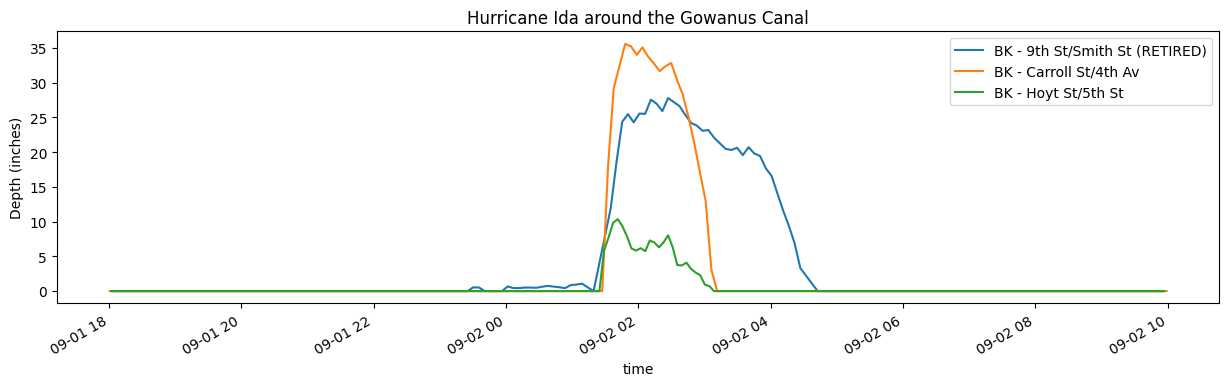

In [ ]:
draw_depth_data(df_depth, "Hurricane Ida around the Gowanus Canal")

### Tropical Storm Henri

In [ ]:
# query depth data for all sensors
df_depth = query_depth_data_for_multiple_deployments(
    df_search,
    start_time="2021-08-21T17:00:00-04:00",
    end_time="2021-08-22T06:00:00-04:00",
)

# show a summary
print(len(df_depth), "results")
df_depth.head()

{'depth_data': [{'deployment_id': 'widely_proud_lizard', 'time': '2021-08-21T21:01:43.648776+00:00', 'depth_proc_mm': 0}, {'deployment_id': 'widely_proud_lizard', 'time': '2021-08-21T21:06:50.983859+00:00', 'depth_proc_mm': 0}, {'deployment_id': 'widely_proud_lizard', 'time': '2021-08-21T21:11:58.320633+00:00', 'depth_proc_mm': 0}, {'deployment_id': 'widely_proud_lizard', 'time': '2021-08-21T21:17:05.806651+00:00', 'depth_proc_mm': 0}, {'deployment_id': 'widely_proud_lizard', 'time': '2021-08-21T21:22:13.296809+00:00', 'depth_proc_mm': 0}, {'deployment_id': 'widely_proud_lizard', 'time': '2021-08-21T21:27:20.740151+00:00', 'depth_proc_mm': 0}, {'deployment_id': 'widely_proud_lizard', 'time': '2021-08-21T21:32:29.167251+00:00', 'depth_proc_mm': 0}, {'deployment_id': 'widely_proud_lizard', 'time': '2021-08-21T21:37:37.218405+00:00', 'depth_proc_mm': 0}, {'deployment_id': 'widely_proud_lizard', 'time': '2021-08-21T21:42:44.253066+00:00', 'depth_proc_mm': 0}, {'deployment_id': 'widely_prou

,deployment_id,depth_proc_mm,name,depth_inches
time,,,,
2021-08-21 21:01:43.648776+00:00,widely_proud_lizard,0,BK - 9th St/Smith St (RETIRED),0.0
2021-08-21 21:06:50.983859+00:00,widely_proud_lizard,0,BK - 9th St/Smith St (RETIRED),0.0
2021-08-21 21:11:58.320633+00:00,widely_proud_lizard,0,BK - 9th St/Smith St (RETIRED),0.0
2021-08-21 21:17:05.806651+00:00,widely_proud_lizard,0,BK - 9th St/Smith St (RETIRED),0.0
2021-08-21 21:22:13.296809+00:00,widely_proud_lizard,0,BK - 9th St/Smith St (RETIRED),0.0


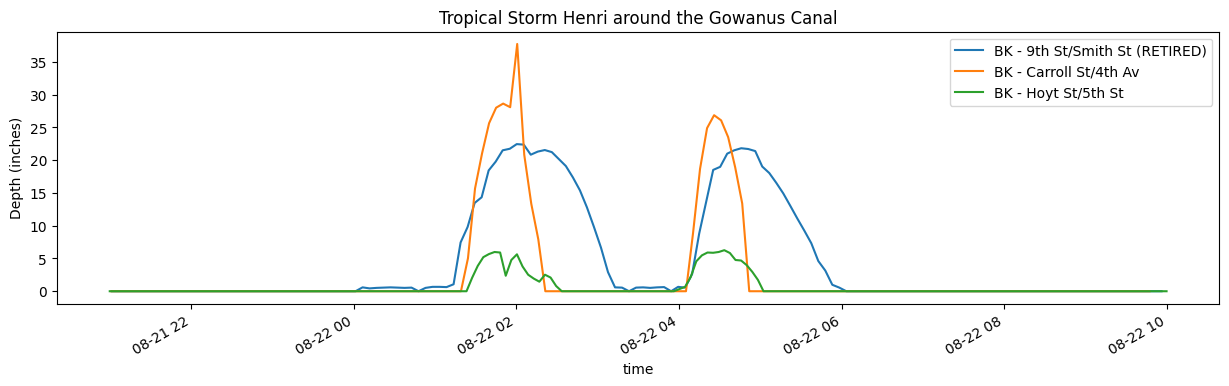

In [ ]:
draw_depth_data(df_depth, "Tropical Storm Henri around the Gowanus Canal")

In [ ]:
# query depth data for all sensors
df_depth = query_depth_data_for_multiple_deployments(
    df_search,
    start_time="2023-09-10T09:00:00-04:00",
    end_time="2023-09-12T06:00:00-04:00",
)

# show a summary
print(len(df_depth), "results")
df_depth.head()

{'depth_data': [{'deployment_id': 'overly_heroic_squid', 'time': '2023-09-10T13:00:04.713+00:00', 'depth_proc_mm': 0}, {'deployment_id': 'overly_heroic_squid', 'time': '2023-09-10T13:01:08.08+00:00', 'depth_proc_mm': 0}, {'deployment_id': 'overly_heroic_squid', 'time': '2023-09-10T13:02:11.297+00:00', 'depth_proc_mm': 0}, {'deployment_id': 'overly_heroic_squid', 'time': '2023-09-10T13:03:14.545+00:00', 'depth_proc_mm': 0}, {'deployment_id': 'overly_heroic_squid', 'time': '2023-09-10T13:04:17.07+00:00', 'depth_proc_mm': 0}, {'deployment_id': 'overly_heroic_squid', 'time': '2023-09-10T13:05:20.159+00:00', 'depth_proc_mm': 0}, {'deployment_id': 'overly_heroic_squid', 'time': '2023-09-10T13:06:23.483+00:00', 'depth_proc_mm': 0}, {'deployment_id': 'overly_heroic_squid', 'time': '2023-09-10T13:07:26.63+00:00', 'depth_proc_mm': 0}, {'deployment_id': 'overly_heroic_squid', 'time': '2023-09-10T13:09:32.826+00:00', 'depth_proc_mm': 0}, {'deployment_id': 'overly_heroic_squid', 'time': '2023-09-10

,deployment_id,depth_proc_mm,name,depth_inches
time,,,,
2023-09-10 13:00:04.713000+00:00,overly_heroic_squid,0,BK - 9th St/Smith St,0.0
2023-09-10 13:01:08.080000+00:00,overly_heroic_squid,0,BK - 9th St/Smith St,0.0
2023-09-10 13:02:11.297000+00:00,overly_heroic_squid,0,BK - 9th St/Smith St,0.0
2023-09-10 13:03:14.545000+00:00,overly_heroic_squid,0,BK - 9th St/Smith St,0.0
2023-09-10 13:04:17.070000+00:00,overly_heroic_squid,0,BK - 9th St/Smith St,0.0


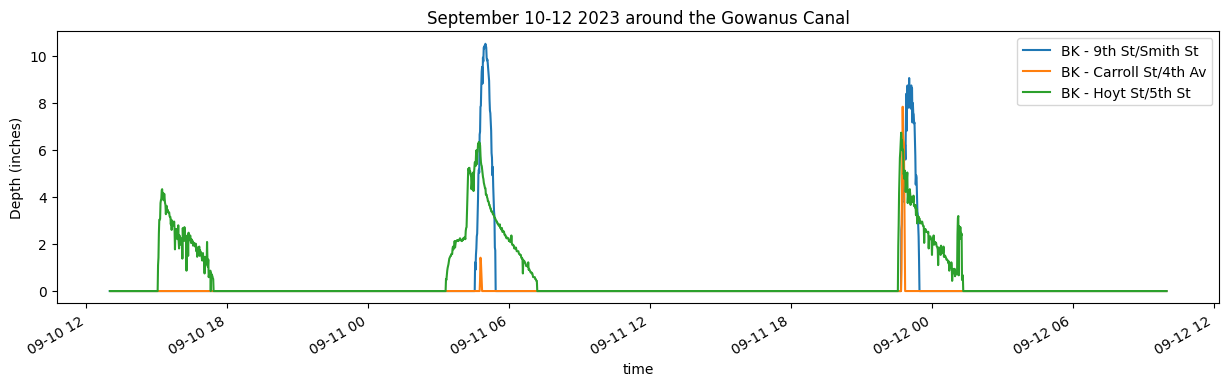

In [ ]:
draw_depth_data(df_depth, "September 10-12 2023 around the Gowanus Canal")

In [ ]:
from datetime import datetime, timedelta
# query depth data for all sensors
df_depth = query_depth_data_for_multiple_deployments(
    df_deployments[df_deployments.deployment_id == 'weekly_poetic_guinea'],
    start_time=(datetime.now() - timedelta(days=1)).isoformat(),
    end_time=datetime.now().isoformat(),
)

# show a summary
print(len(df_depth), "results")
df_depth.head()

{'depth_data': [{'deployment_id': 'weekly_poetic_guinea', 'time': '2024-04-30T18:45:50.982+00:00', 'depth_proc_mm': 888}, {'deployment_id': 'weekly_poetic_guinea', 'time': '2024-04-30T19:02:39.39+00:00', 'depth_proc_mm': 891}, {'deployment_id': 'weekly_poetic_guinea', 'time': '2024-04-30T19:05:47.933+00:00', 'depth_proc_mm': 893}, {'deployment_id': 'weekly_poetic_guinea', 'time': '2024-04-30T19:07:53.752+00:00', 'depth_proc_mm': 889}, {'deployment_id': 'weekly_poetic_guinea', 'time': '2024-04-30T19:13:09.811+00:00', 'depth_proc_mm': 892}, {'deployment_id': 'weekly_poetic_guinea', 'time': '2024-04-30T19:16:27.096+00:00', 'depth_proc_mm': 892}, {'deployment_id': 'weekly_poetic_guinea', 'time': '2024-04-30T20:13:07.683+00:00', 'depth_proc_mm': 895}, {'deployment_id': 'weekly_poetic_guinea', 'time': '2024-04-30T20:50:53.041+00:00', 'depth_proc_mm': 897}, {'deployment_id': 'weekly_poetic_guinea', 'time': '2024-04-30T21:23:25.127+00:00', 'depth_proc_mm': 895}, {'deployment_id': 'weekly_poeti

,deployment_id,depth_proc_mm,name,depth_inches
time,,,,
2024-04-30 18:45:50.982000+00:00,weekly_poetic_guinea,888,BK - Carroll St/4th Av,34.96063
2024-04-30 19:02:39.390000+00:00,weekly_poetic_guinea,891,BK - Carroll St/4th Av,35.07874
2024-04-30 19:05:47.933000+00:00,weekly_poetic_guinea,893,BK - Carroll St/4th Av,35.15748
2024-04-30 19:07:53.752000+00:00,weekly_poetic_guinea,889,BK - Carroll St/4th Av,35.00000
2024-04-30 19:13:09.811000+00:00,weekly_poetic_guinea,892,BK - Carroll St/4th Av,35.11811


## Coming early 2024: querying specific events

 - Query storm events (e.g. Hurricane Henri, certain dates, etc.)
 - Query data between event start/stop times